## Requirements

In [1]:
import random
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np

## Problem

An ant walks the edges of an $n$-dimensional hypercube at random.  It starts at a corner, what is the expected number of edges it traverses before reaching the opposite corner?

## Theory

### Algebraic solution

For $n = 3$, you can reason as follows.  Let $E_0$ be the average number of steps to reach the opposite corner from the origin.  Let $E_1$ be the average number of steps required from a corner on step away from the origin.  Let $E_2$ be the average number of steps required at a corner two steps removed from the origin.

Now, starting from the origing, since one step is taken and you are guaranteed to end up in a corner one step removed from the origin, you have:
$$
  E_0 = 1 + E_1
$$

At each corner, the ant can pick from three edges to follow.

For $E_1$, at a corner one step removed from the origin, there are two possible outcomes:
1. either the ant goes back to the origin with a probability of $1/3$, or
2. it goes to a corner two steps removed from the origin with a probability of $2/3$.

$$
  E_1 = 1 + \frac{1}{3}E_0 + \frac{2}{3}E_2
$$

Finally, in a corner two steps removed from the origin, there are again two possible outcomes:
1. either the ant goes back to a corner only one step removed from the origin with a probability
   of $2/3$, or
2. it goes to its destination with a probability of $1/3$.

However, if it does the latter, no more steps need to be taken, hence:
$$
  E_2 = 1 + \frac{2}{3}E_1
$$

Substituting $E_2$ into the equation for $E_1$ yields:
$$
  E_1 = 1 + \frac{1}{3}E_0 + \frac{2}{3} + \frac{4}{9}E_1
$$
or
$$
  \begin{array}{rcl}
    E_1 & = & \frac{9}{5}\left( \frac{5}{3} + \frac{1}{3} E_0 \right) \\
        & = & 3 + \frac{3}{5} E_0
  \end{array}
$$
Substituting $E_1$ into the first equation yields:
$$
  E_0 = 4 + \frac{3}{5} E_0
$$
or
$$
  E_0 = 10
$$
and hence
$$
  \begin{array}{rcl}
    E_1 & = & 9 \\
    E_2 & = & 7
  \end{array}
$$

### Markov process

Alternatively, this can be viewed as a Markov process as transition probabilities only depend on the current position, not on how the ant got there.

The transition matrix is given by:
$$
  P = \left(
    \begin{array}{cccc}
      0           & 1           & 0           & 0 \\
      \frac{1}{3} & 0           & \frac{2}{3} & 0 \\
      0           & \frac{2}{3} & 0           & \frac{1}{3} \\
      0           & 0           & 0           & 1
    \end{array}
  \right)
$$
The Markov process has $r = 1$ absorbing state (the opposite corner), and $t = 3$ transient states, so the matrix $P$ can be written as:
$$
  P = \left(
    \begin{array}{cc}
      Q_t     & R_{t, r} \\
      O_{r,t} & I_r
    \end{array}
  \right)
$$
Here, $0_{r, t}$ denotes a $r \times t$ zero matrix and $I_r$ an $r \times r$ identity matrix, respectively.  The matrix $Q_t$ denotes an $t \times t$ the elements of which are the transition probabilities between the transient states, and the matrix $R_{t, r}$ has elements that denote the probability to reach an absorption state from a transient state.

The probabilities to be in a transient state after $k$ steps is given by $Q_t^k$, and hence, for all possible paths through the states:
$$
  \sum_{k=0}^{\infty} Q_t^k = \left(I_t - Q_t \right)^{-1}
$$

The expected number of steps to reach an absorbing state is now given by:
$$
  \left(I_t - Q_t \right)^{-1} \mathbb{1}_t
$$
where $\mathbb{1}_t$ is a vector of all ones.

As for $n = 3$ the matrix $Q_3$ is given by:
$$
  Q_3 = \left(
    \begin{array}{ccc}
      0           & 1           & 0 \\
      \frac{1}{3} & 0           & \frac{2}{3} \\
      0           & \frac{2}{3} & 0
    \end{array}
  \right)
$$
the matrix $I_3 - Q_3$ is given by:
$$
  Q_3 = \left(
    \begin{array}{ccc}
      -1           & 1            & 0 \\
      -\frac{1}{3} & 1            & -\frac{2}{3} \\
      0            & -\frac{2}{3} & 1
    \end{array}
  \right)
$$
This is exactly the matrix you get when writing the set of equations for $E_0$, $E_1$ and $E_2$ in matrix notation, and indeed,
$$
  \left( I_3 - Q_3 \right) \cdot E = \mathbb{1}_3
$$
has the expression given above as its solution:
$$
  E = \left( I_3 - Q_3 \right)^{-1} \cdot \mathbb{1}_3
$$

This can be done numerically using `numpy`.

In [2]:
Q = np.array([
    [0, 1, 0],
    [1/3, 0, 2/3],
    [0, 2/3, 0],
])

In [3]:
np.linalg.inv(np.eye(3) - Q)@np.ones(3)

array([10.,  9.,  7.])

Indeed, the expected number of steps from the origin is indeed 10, consistent with the simpler algebraic approach.

## Simulation

The corners of an $n$-dimensional hypercube can be represented as $n$-tuples the elements of which can have the values 0 and 1.  The origin is $(0, \cdots, 0)$ and the destination, the "opposite" corner is $(1, \cdots, 1)$.  Moving along an edge from one corner to another boils down to changing one conponent from a 0 to a 1, or vice versa.

Hence each step corresponds to changing a single component of an $n$-tuple.

For good measure, you can define a type to represent a position.

In [4]:
type Position = list[Literal[0, 1]]

As this is Python, and `tuple` is immutable, a `list` is more convenient if you want to modify a position.

For convenience, you can define a number of functions, the first one initializes the start position, i.e., the origin.

In [5]:
def create_start_position(n: int) -> Position:
    return [0 for _ in range(n)]

The second function performs a move along a randomly chosen edge of the hypercube.

In [6]:
def move_randomly(position: Position) -> None:
    idx = random.randrange(len(position))
    position[idx] = 0 if position[idx] else 1

The third function checks whether the opposite corner has been reached.

In [7]:
def has_reached_target(position: Position) -> bool:
    return all(position)

The function `walk` lets the ant move until it reaches the opposite corner, keeping track of and returning the number of steps the process required.

In [8]:
def walk(n: int) -> int:
    nr_steps = 0
    position = create_start_position(n)
    while not has_reached_target(position):
        move_randomly(position)
        nr_steps += 1
    return nr_steps

The last function lets the ant make many walks, and returns the average number of steps taken.

In [9]:
def expected_walk_length(n: int, nr_walks: int) -> float:
    expected_length = 0.0
    for _ in range(nr_walks):
        expected_length += walk(n)
    return expected_length/nr_walks

### n = 3

In [10]:
expected_walk_length(3, 100_000)

10.03866

For $n = 3$, the average number of steps is indeed close to 10, as you expected from the theoretical analysis.

### n = 4

For $n = 4$, you can compute the expected number of steps again using the Markov approach.

In [11]:
Q = np.array([
    [0, 1, 0, 0],
    [1/4, 0, 3/4, 0],
    [0, 1/2, 0, 1/2],
    [0, 0, 3/4, 0],
])

In [12]:
np.linalg.inv(np.eye(4) - Q)@np.ones(4)

array([21.33333333, 20.33333333, 18.66666667, 15.        ])

So the theoretical result is 21.333.

In [13]:
expected_walk_length(4, 100_000)

21.24434

Again, the simulation agrees very well to the theoretical result.

### n = 5

In [14]:
Q = np.array([
    [0, 1, 0, 0, 0],
    [1/5, 0, 4/5, 0, 0],
    [0, 2/5, 0, 3/5, 0],
    [0, 0, 3/5, 0, 2/5],
    [0, 0, 0, 4/5, 0],
])

In [15]:
np.linalg.inv(np.eye(5) - Q)@np.ones(5)

array([42.66666667, 41.66666667, 40.16666667, 37.5       , 31.        ])

In [16]:
expected_walk_length(5, 100_000)

42.62022

## Theory: generalization

When looking at $Q_3$, $Q_4$ and $Q_5$, it is easy to spot the general pattern for $Q \in \mathbb{R}^{n \times n}$:
$$
  q_{i j} = \begin{cases}
    \frac{i}{n} & \text{if $j = i - 1$} \\
    \frac{n - i}{n} & \text{if $j = i + 1$} \\
    0 & \text{otherwise}
  \end{cases}
$$
where $i, j \in \{0, \dots, n - 1\}$.

Now it is easy to write a function that computes the theoretical value for the expected number of steps for an ant moving on an $n$-dimensional hypercube.

In [17]:
def theoretical_expected_walk_length(n: int) -> float:
    i = np.arange(n - 1)          # 0..n-2
    sub = (i + 1) / n             # q_{i,i-1} for i=1..n-1
    sup = (n - i) / n             # q_{i,i+1} for i=0..n-2
    Q = np.diag(sub, k=-1) + np.diag(sup, k=1)
    return np.linalg.inv(np.eye(n) - Q)@np.ones(n)

Just to confirm, indeed the result is the same as for a $Q$ matrix produced by hand.

In [18]:
theoretical_expected_walk_length(5)

array([42.66666667, 41.66666667, 40.16666667, 37.5       , 31.        ])

This can be visualized in a plot.

In [19]:
ns = np.arange(2, 21, 1)
Es = [theoretical_expected_walk_length(n)[0] for n in ns]

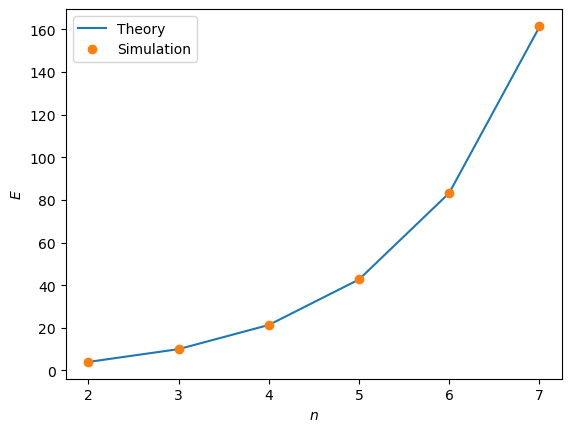

In [20]:
plt.plot(ns[:6], Es[:6], label='Theory')
plt.plot(ns[:6], [expected_walk_length(n, 100_000) for n in ns[:6]], 'o', label='Simulation')
plt.xlabel('$n$')
plt.ylabel('$E$')
plt.legend();

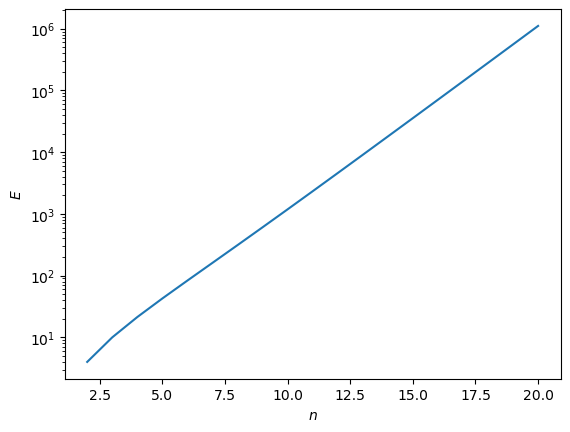

In [21]:
plt.plot(ns, Es)
plt.xlabel('$n$')
plt.ylabel('$E$')
plt.yscale('log');

It is clear that $E$ grows exponentially as a function of $n$.